In [1]:
import pandas as pd 
import anndict as adt
import scanpy as sc

adt.configure_llm_backend('openai',
    'gpt-4o',
    api_key='Your API key'
)
adata = sc.read_h5ad('/maiziezhou_lab2/yuling/datasets/Kidney/Xenium/time_Hour4L.h5ad')
adata.obs['tissue'] = 'transition from acute kidney injury to chronic kidney disease'
sc.pp.normalize_total(adata) # Normalize
sc.pp.log1p(adata) # Log
sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset=False) # Set highly variable genes
sc.pp.scale(adata) # Scale
sc.tl.pca(adata, n_comps=50) # PCA
sc.pp.neighbors(adata) # Neighborhood graph
sc.tl.umap(adata) # UMAP
adata_dict = adt.build_adata_dict(adata, ['tissue'])
#appropriate_resolution_dict = adt.wrappers.ai_determine_leiden_resolution_adata_dict(adata_dict, initial_resolution=0.5)
sc.tl.leiden(adata, resolution = 0.4) # Cluster
df = pd.read_csv('/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/banksy/Kidney/Hour4L_BANKSY.csv',index_col=0)
# adata.obs['leiden'] = pd.Categorical(df.loc[adata.obs_names, 'clust_M1_lam0.2_mclust9'].astype(str))
# print(adata.obs['leiden'])
# Get the model name directly from the LLM config (just for naming the column in .obs)
model = adt.get_llm_config()['model']
# Use an LLM to annotate celltypes based on the 'leiden' column, pass tissue information from 'tissue' column.
# The column containing the new labels will be in adata.obs[label_column]
new_label_column = f'{model}_ai_cell_type'
adata.obs['leiden'] = pd.Categorical(
    df.loc[adata.obs_names, 'clust_M1_lam0.2_mclust20'].astype(str)
)
sc.tl.rank_genes_groups(adata, groupby='leiden', use_raw=False)
new_label_column = f'{model}_ai_cell_type'
label_results = adt.ai_annotate_cell_type(
    adata,
    groupby='leiden',
    n_top_genes=10,
    new_label_column=new_label_column,
    tissue_of_origin_col='tissue'
)
print("label_results:", label_results)
print("NaN count:", adata.obs[new_label_column].isna().sum())
print("unique non-null:", adata.obs[new_label_column].dropna().unique())
#adata.obs[new_label_column] = adata.obs[new_label_column].fillna("Unknown cell type").astype(str).str.strip()
ai_label_column = f'{model}_simplified_ai_cell_type'
simplified_mappings = adt.simplify_obs_column(
    adata, new_label_column, ai_label_column, simplification_level='redundancy-removed'
)

/home/zhuy45/miniconda3/envs/adt/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/zhuy45/miniconda3/envs/adt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_3909572/3636783712.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.4) # Cluster
/home/zhuy45/miniconda3/envs/adt/lib/python3.12/site-packages/scanpy/tools/_rank_g

label_results:    leiden                 gpt-4o_ai_cell_type  \
0       1                         Macrophage.   
1      10                 Intercalated cells.   
2      11     Distal convoluted tubule cells.   
3      12              Proximal tubule cells.   
4      13                          Pericytes.   
5      14                            Podocyte   
6      15     Distal convoluted tubule cells.   
7      16              Proximal tubule cells.   
8      17                          Pericytes.   
9      18              Proximal tubule cells.   
10     19              Proximal tubule cells.   
11      2                     Myofibroblasts.   
12     20         Thick ascending limb cells.   
13      3                  Endothelial cells.   
14      4  Proximal tubular epithelial cells.   
15      5              Proximal tubule cells.   
16      6              Proximal tubule cells.   
17      7         Thick ascending limb cells.   
18      8              Proximal tubule cells.   
19   

In [2]:
adata.obs['gpt-4o_ai_cell_type'].unique()

['Proximal tubule cells.', 'Endothelial cells.', 'Myofibroblasts.', 'Macrophage.', 'Intercalated cells.', 'Distal convoluted tubule cells.', 'Pericytes.', 'Thick ascending limb cells.', 'Podocyte', 'Proximal tubular epithelial cells.']
Categories (10, object): ['Distal convoluted tubule cells.', 'Endothelial cells.', 'Intercalated cells.', 'Macrophage.', ..., 'Podocyte', 'Proximal tubular epithelial cells.', 'Proximal tubule cells.', 'Thick ascending limb cells.']

Plotting UMAP for key: transition from acute kidney injury to chronic kidney disease


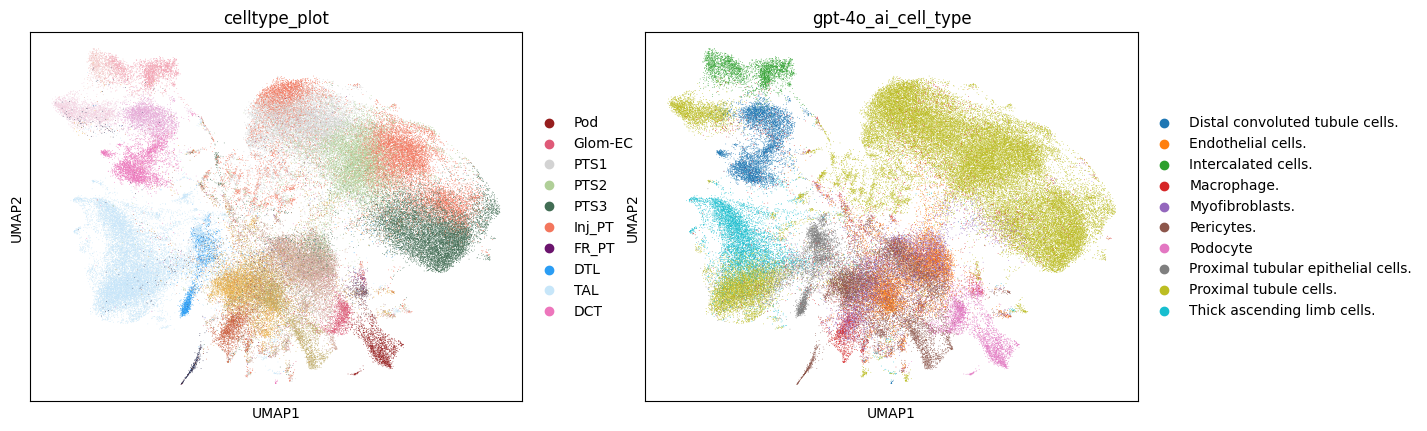

In [3]:
adata_dict = {'transition from acute kidney injury to chronic kidney disease': adata}
adt.wrappers.plot_umap_adata_dict(adata_dict, color=['celltype_plot', 'gpt-4o_ai_cell_type'])

In [4]:

rows = [
    # Proximal tubule
    "PTS1", "PTS2", "PTS3", "FR_PT", "Inj_PT",
    # Loop of Henle
    "DTL", "TAL",
    # Distal nephron
    "DCT", "CNT", "PC", "ICA",
    # Glomerulus
    "Pod", "PEC", "Glom-EC",
    # Vasculature / stroma
    "EC", "Per-SMC", "Fib",
    # Urothelial
    "Uro",
    # Immune
    "Immune",
    # Other
    "ICB"
]

annot_to_cluster = [
    # Proximal tubule
    "Proximal tubule cells.",
    "Proximal tubular epithelial cells.",

    # Loop of Henle
    "Thick ascending limb cells.",

    # Distal nephron
    "Distal convoluted tubule cells.",
    "Intercalated cells.",

    # Glomerulus
    "Podocyte",
    # Vasculature / stroma
    "Endothelial cells.",
    "Pericytes.",
    "Myofibroblasts.",
    # Immune
    "Macrophage."
]
adata.obs["celltype_plot"] = pd.Categorical(
    adata.obs["celltype_plot"],
    categories= rows,
    ordered=True
)

adata.obs["gpt-4o_ai_cell_type"] = pd.Categorical(
    adata.obs["gpt-4o_ai_cell_type"],
    categories= annot_to_cluster,
    ordered=True
)

In [7]:
#unify the labels from the different adata in the adata_dict (i.e. use an LLM to merge categories like 'Macrophage' and 'macrophages.')
#this allows calculation of kappa
manual_cell_type_col = 'celltype_plot'
label_map_with_manual = adt.ensure_label_consistency_adata(adata, [ai_label_column, manual_cell_type_col], simplification_level='unified', new_col_prefix='unified')

In [8]:
label_map_with_manual

{'Podocyte': 'Podocyte',
 'Myofibroblast': 'Myofibroblast',
 'Pericyte': 'Pericyte',
 'Immune': 'Immune Cell',
 'DTL': 'Descending Thin Limb Cell',
 'PTS2': 'Proximal Tubule Cell',
 'Macrophage': 'Macrophage',
 'FR_PT': 'Proximal Tubule Cell',
 'Glom-EC': 'Glomerular Endothelial Cell',
 'PTS3': 'Proximal Tubule Cell',
 'Per-SMC': 'Pericyte',
 'ICA': 'Intercalated Cell',
 'Distal Convoluted Tubule Cell': 'Distal Convoluted Tubule Cell',
 'PTS1': 'Proximal Tubule Cell',
 'ICB': 'Intercalated Cell',
 'Intercalated Cell': 'Intercalated Cell',
 'Endothelial Cell': 'Endothelial Cell',
 'CNT': 'Connecting Tubule Cell',
 'Pod': 'Podocyte',
 'Thick Ascending Limb Cell': 'Thick Ascending Limb Cell',
 'Proximal Tubule Cell': 'Proximal Tubule Cell',
 'TAL': 'Thick Ascending Limb Cell',
 'DCT': 'Distal Convoluted Tubule Cell',
 'Inj_PT': 'Injured Proximal Tubule Cell',
 'Fib': 'Fibroblast',
 'PC': 'Principal Cell',
 'EC': 'Endothelial Cell',
 'PEC': 'Parietal Epithelial Cell',
 'Uro': 'Urothelial C

In [9]:
#get unified cols
unified_cell_types = adt.get_adata_columns(adata, contains=['unified'])
unified_cell_types

['unified_celltype_plot', 'unified_gpt-4o_simplified_ai_cell_type']

In [10]:
#assess accuracy compared to manual (for benchmarking)
label_agreement_binary = adt.ai_compare_cell_type_labels_pairwise(adata, [unified_cell_types[0]], [unified_cell_types[1]], new_col_prefix='binary_agreement', comparison_level='binary')
label_agreement_categorical = adt.ai_compare_cell_type_labels_pairwise(adata, [unified_cell_types[0]], [unified_cell_types[1]], new_col_prefix='categorical_agreement', comparison_level='categorical')

In [11]:
#get the agreement columns
binary_agreement_cols = adt.get_adata_columns(adata, contains = ['binary_agreement'])
categorical_agreement_cols = adt.get_adata_columns(adata, contains = ['categorical_agreement'])

In [12]:
#change scale of categorical label agreement cols from 0 to 1 (raw has values 0, 1, and 2)
adata.obs[categorical_agreement_cols] = adata.obs[categorical_agreement_cols]/2

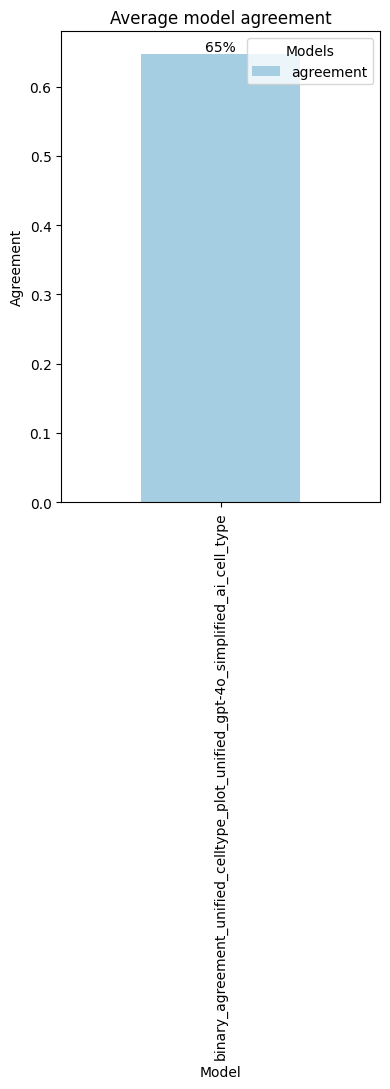

In [13]:
#plot the agreement at the binary level
agreement_plot_overall_binary = adt.plot_model_agreement(adata, group_by=manual_cell_type_col, sub_group_by='tissue', agreement_cols=binary_agreement_cols, granularity=0)

#clean plot up for display
import matplotlib.pyplot as plt
def set_xticks_rotation_and_resize(fig_ax_tuple):
    fig, ax = fig_ax_tuple
    fig.set_size_inches((4, 11))
    fig.tight_layout()  # Adjust layout to fit the new size
    
    # Rotate x-axis tick labels
    for label in ax.get_xticklabels():
        label.set_rotation(90)
    
    # Check if legend exists and update labels if necessary
    legend = ax.get_legend()
    if legend:
        # Define label mapping
        label_mapping = {'0.0': 'No', '0.5': 'Partial', '1.0': 'Perfect'}
        
        # Iterate over legend texts and update if in mapping
        for text in legend.get_texts():
            original_label = text.get_text()
            new_label = label_mapping.get(original_label, original_label)
            text.set_text(new_label)
set_xticks_rotation_and_resize(agreement_plot_overall_binary)

/home/zhuy45/miniconda3/envs/adt/lib/python3.12/site-packages/anndict/plot/agreement_bar_plots.py:349: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = melted.groupby(['model_name', 'agreement']).size().reset_index(name='count')
/home/zhuy45/miniconda3/envs/adt/lib/python3.12/site-packages/anndict/plot/agreement_bar_plots.py:390: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


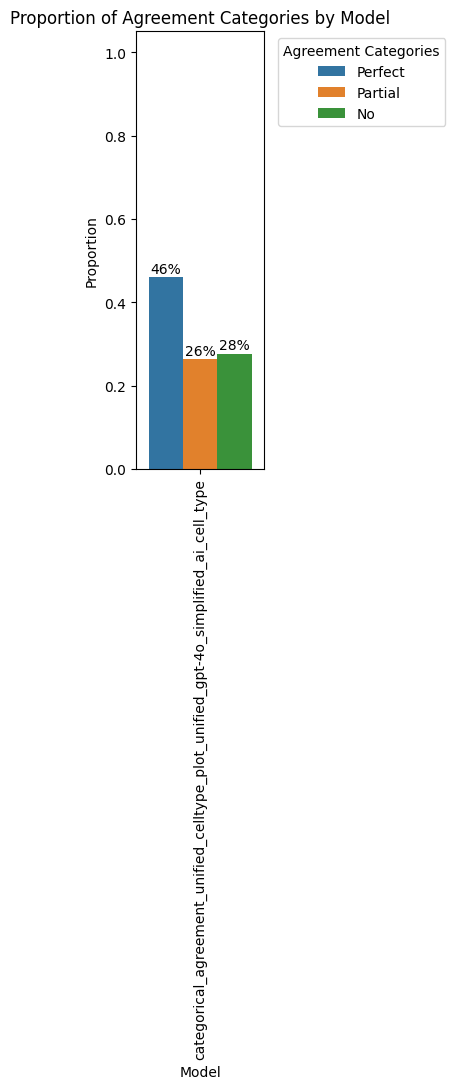

In [14]:
#plot the agreement at the binary level
agreement_plot_overall_categorical = adt.plot_model_agreement_categorical(adata, group_by=manual_cell_type_col, sub_group_by='tissue', agreement_cols=categorical_agreement_cols, granularity=0)

#clean plot up for display
set_xticks_rotation_and_resize(agreement_plot_overall_categorical)